# 08c: NUTS + Closed-Form Validation + Bayesian Diagnostics

Validates the EKF + NUTS inference machinery on the (μ, σ) framework (Bayesian.md §1.2 / §2.3), using the closed-form analytical policy. Mathematically EKF reduces to standard Kalman here: the policy is exactly linear in the latent state, so $H_2 = \rho/(1-\alpha)$ is constant and the Taylor remainder is zero. The code path is the same EKF that 08d's NN run uses. A pass here demonstrates the framework operates correctly on the panel; any remaining gap in 08d is attributable to the NN surrogate.

**Notebook structure.** Section 3 is the headline single-run posterior result. Sections 4-6 are the validation/analysis layers from Bayesian.md §1.4, exercised here at small demo budgets:

| § | What | Per-MODE cost target |
|---|---|---|
| 1-3 | Single-run posterior at the chosen `MODE` profile | CPU_SMOKE ~3 min, CPU_LARGE ~20 min |
| 4 | Coverage check (Layer-B SBC-lite, $R$ scales with MODE; per-rep inner MCMC fixed) | ~2.5 min @ R=5; ~5 min @ R=10 |
| 5 | Posterior predictive check (100 draws @ observed shape; sub-second) | ~2 s |
| 6 | Prior sensitivity sweep (3 std-prior variants; per-variant inner MCMC fixed) | ~1.5 min |
| **Total** | | **~7 min** (CPU_SMOKE) / **~27 min** (CPU_LARGE) |

The §4 coverage helper (`run_coverage_check`), §5 PPC helper (`run_posterior_predictive_check`), and §6 sensitivity helper (`run_prior_sensitivity`) all live in [src/v2/estimation/bayesian.py](../src/v2/estimation/bayesian.py). All three are spec-agnostic: the same demos plug into 08d's NN-surrogate spec by swapping `make_closed_form_bayesian_spec` for `make_neural_bayesian_spec` (deferred until 08d's NUTS+NN run completes).

**Known limitation: multimodal posterior on (α, investment_mean).** The structural ridge $\kappa(\alpha) + \mu_{\xi^k} = \text{const}$ creates an alternative posterior mode that chains can get stuck in (R-hat in hundreds for affected params; see Bayesian.md §1.2 identification discussion). The dominant mode recovers truth correctly; the secondary mode is a known artifact of weak identification along the κ(α) ridge. Reporting the marginal CIs from pooled chains is honest about the posterior shape but conservative on precision. Fixes (reparameterization, parallel tempering) are deferred.

Loads the panel bundle from [08a](08a_pretrain_nn_surrogate.ipynb). Outputs land under `outputs/notebooks/08c_nuts_closedform_validation/{MODE}/`. Per-section artifacts: `posterior_summary.csv`, `trace.png`, `marginals.png`, `posterior_correlation.png` (§3); `coverage_summary.csv`, `coverage_intervals.png` (§4); `ppc_summary.csv`, `ppc_distributions.png` (§5); `sensitivity_summary.csv`, `sensitivity_movement.csv`, `sensitivity_comparison.png` (§6).

## Section 0: Setup

In [ ]:
from pathlib import Path
from functools import partial
import json
import os
import sys
import time
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
warnings.filterwarnings("ignore", message=r".*does not produce the same series as CPU implementation.*")
warnings.filterwarnings("ignore", message=r".*casting an input of type complex64.*")

_REPO_ROOT = None
for _rr_candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_rr_candidate / "src" / "v2").exists():
        _REPO_ROOT = _rr_candidate
        break
if _REPO_ROOT is None:
    import importlib.util as _rr_ilu
    _rr_spec = _rr_ilu.find_spec("src.v2")
    if _rr_spec is not None and _rr_spec.origin is not None:
        _REPO_ROOT = Path(_rr_spec.origin).resolve().parents[2]
if _REPO_ROOT is None:
    raise RuntimeError("Could not find repo root containing src/v2.")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

import tensorflow as tf
tf.config.set_visible_devices([], "GPU")
tf.get_logger().setLevel("ERROR")

from src.v2.environments.basic_investment import EconomicParams, ShockParams
from src.v2.environments.parameterized_basic_investment import ParameterizedBasicInvestmentEnv
from src.v2.estimation import (
    BayesianCoverageConfig,
    BayesianRunConfig,
    PosteriorPredictiveConfig,
    run_coverage_check,
    run_mcmc,
    run_posterior_predictive_check,
    run_prior_sensitivity,
)
from src.v2.estimation.bayesian_basic_investment import make_closed_form_bayesian_spec
from src.v2.estimation.beta_sampler import DEFAULT_UNIFORM_BOUNDS
from src.v2.utils.seeding import fold_in_seed

np.set_printoptions(precision=4, suppress=True)

# ---- Profile selection -------------------------------------------------------
# Section 3 (single-run posterior) scales with MODE.  Sections 4 (coverage)
# and 6 (sensitivity) use mode-independent INNER specs below; only `cov_R`
# scales with MODE.  PPC (Section 5) is sub-second regardless.
MODE = "CPU_SMOKE"   # CPU_SMOKE (~7 min total) | CPU_LARGE (~27 min total)
PROFILES = {
    "CPU_SMOKE": dict(
        n_chains=4, n_warmup=1000, n_samples=500,
        n_firms=20, horizon=10, target_accept_prob=0.90,
        cov_R=5,            # coverage replicates
        ppc_n_draws=100,    # posterior-predictive draws
    ),
    "CPU_LARGE": dict(
        n_chains=4, n_warmup=1000, n_samples=500,
        n_firms=50, horizon=20, target_accept_prob=0.90,
        cov_R=10,
        ppc_n_draws=100,
    ),
}
P = PROFILES[MODE]

# Inner specs for §4 coverage and §6 sensitivity (mode-independent: keeps
# per-replicate / per-variant compute predictable across MODEs).
COVERAGE_INNER     = dict(n_chains=2, n_warmup=500, n_samples=200,
                          n_firms=15, horizon=10, target_accept_prob=0.90)
SENSITIVITY_INNER  = dict(n_chains=2, n_warmup=500, n_samples=200,
                          target_accept_prob=0.90)

# Prior variants for §6 sensitivity.  Sweep the std-priors of the (μ, σ)
# framework (Bayesian.md §1.2); structural-triple uniforms and the
# Normal(0, 0.1) mean priors are held fixed.  "default" matches the §1.2
# baseline that the headline Section 3 posterior uses.
SENSITIVITY_VARIANTS = {
    "tight":   dict(production_std_prior_scale=0.1, investment_std_prior_scale=0.1),
    "default": dict(production_std_prior_scale=0.5, investment_std_prior_scale=0.5),
    "loose":   dict(production_std_prior_scale=1.0, investment_std_prior_scale=1.0),
}

# ---- Load bundle (panel + env metadata only; NN not used in this baseline check) ----
BUNDLE_BASE = _REPO_ROOT / "outputs" / "notebooks" / "08a_pretrain_nn_surrogate" / "shac_full_frictionless"
if not BUNDLE_BASE.with_suffix(".meta.json").exists():
    raise FileNotFoundError(f"Bundle not found at {BUNDLE_BASE}.*. Run 08a first.")

meta = json.loads(BUNDLE_BASE.with_suffix(".meta.json").read_text())
panel_full = dict(np.load(BUNDLE_BASE.with_suffix(".panel.npz")))

param_env = ParameterizedBasicInvestmentEnv(
    nominal_econ=EconomicParams(**meta["env"]["nominal_econ"]),
    nominal_shocks=ShockParams(**meta["env"]["nominal_shocks"]),
    bounds=meta["env"]["bounds"],
)
beta_true   = meta["ground_truth_beta"]
MASTER_SEED = tuple(meta["master_seed"])

RUN_DIR = _REPO_ROOT / "outputs" / "notebooks" / "08c_nuts_closedform_validation" / MODE
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"MODE = {MODE}; profile = {P}")
print(f"Bundle loaded: panel y={panel_full['y'].shape}, β_true = {beta_true}")
print(f"RUN_DIR = {RUN_DIR}")

In [2]:
# Section 1: Spec + observed slice (closed-form policy; profile from MODE).
spec = make_closed_form_bayesian_spec(param_env)

N_slice, T_slice = int(P["n_firms"]), int(P["horizon"])
observed = {
    "y":          panel_full["y"][:N_slice,          :T_slice, np.newaxis].astype(np.float32),
    "log_k":      panel_full["log_k"][:N_slice,      :T_slice, np.newaxis].astype(np.float32),
    "log_k_next": panel_full["log_k_next"][:N_slice, :T_slice, np.newaxis].astype(np.float32),
}
print(f"Panel slice: {N_slice} firms x {T_slice} model-time periods; "
      f"batch = {P['n_chains'] * N_slice * T_slice}")

Panel slice: 20 firms x 10 model-time periods; batch = 800


In [3]:
# Section 2: Run MCMC.
mcmc_seed = fold_in_seed(MASTER_SEED, "mcmc")
cfg = BayesianRunConfig(
    n_chains=P["n_chains"], n_warmup=P["n_warmup"], n_samples=P["n_samples"],
    target_accept_prob=P["target_accept_prob"], master_seed=tuple(MASTER_SEED),
)
print(f"Running MCMC: {cfg.n_chains} chains x ({cfg.n_warmup} warmup + {cfg.n_samples} samples)...")
t0 = time.time()
result = run_mcmc(spec, observed, cfg, seed=tuple(mcmc_seed))
mcmc_wall_sec = time.time() - t0
md_meta = result.metadata
print(f"MCMC wall = {mcmc_wall_sec:.1f}s   acceptance = {result.acceptance_rate:.3f}")
print(f"Mean leapfrog steps per iter: {md_meta['mean_leapfrog_steps']:.1f}  "
      f"(max {md_meta['max_leapfrog_steps']}, divergences {md_meta['divergence_count']})")

Running MCMC: 4 chains x (1000 warmup + 500 samples)...
MCMC wall = 758.1s   acceptance = 0.936
Mean leapfrog steps per iter: 85.8  (max 255, divergences 0)


## Section 3: Report

Posterior summary, trace plot, and marginals. Pass criterion: truth in 95% CI for every parameter.

In [4]:
rows = []
for name in spec.parameter_names:
    s  = result.posterior_samples[name]
    lo = float(np.quantile(s, 0.025))
    hi = float(np.quantile(s, 0.975))
    rows.append({
        "parameter": name,
        "true":      beta_true[name],
        "median":    float(np.median(s)),
        "ci_2.5":    lo,
        "ci_97.5":   hi,
        "r_hat":     float(result.r_hat[name]),
        "ess":       float(result.ess[name]),
        "pass":      bool(lo <= beta_true[name] <= hi),
    })
posterior_table = pd.DataFrame(rows)
print(f"Posterior summary (pass rate = {posterior_table['pass'].sum()} / {len(posterior_table)}):")
display(posterior_table)
posterior_table.to_csv(RUN_DIR / "posterior_summary.csv", index=False)

Posterior summary (pass rate = 7 / 7):


,parameter,true,median,ci_2.5,ci_97.5,r_hat,ess,pass
0,alpha,0.50,0.488494,0.468686,0.509862,1.005456,719.688538,True
1,rho,0.50,0.506741,0.480974,0.534729,0.998927,919.339478,True
2,sigma_epsilon,0.24,0.236216,0.212863,0.264475,0.999178,1129.999268,True
3,production_mean,0.00,0.021052,-0.049035,0.089476,1.003445,991.541016,True
4,production_std,0.05,0.029348,0.001824,0.063054,1.011036,698.149048,True
5,investment_mean,-0.10,-0.008340,-0.194334,0.158144,1.006496,677.620422,True
6,investment_std,0.05,0.063023,0.029460,0.074049,1.007850,567.112488,True


In [ ]:
fig, axes = plt.subplots(len(spec.parameter_names), 1,
                          figsize=(9, 1.5 * len(spec.parameter_names)), sharex=True)
for ax, name in zip(axes, spec.parameter_names):
    samples = result.posterior_samples[name]
    for c in range(samples.shape[1]):
        ax.plot(samples[:, c], lw=0.4, alpha=0.8, label=f"chain {c}")
    ax.axhline(beta_true[name], color="k", lw=1.0, ls="--", label="true")
    ax.set_ylabel(name); ax.legend(loc="upper right", fontsize=7, frameon=False)
axes[-1].set_xlabel("post-warmup sample index")
plt.suptitle("Trace (08c NUTS + closed-form validation)")
plt.tight_layout()
plt.savefig(RUN_DIR / "trace.png", dpi=140, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, len(spec.parameter_names),
                          figsize=(2.5 * len(spec.parameter_names), 3))
for ax, name in zip(axes, spec.parameter_names):
    samples = result.posterior_samples[name].reshape(-1)
    ax.hist(samples, bins=40, alpha=0.7, density=True, color="steelblue")
    ax.axvline(beta_true[name], color="k", lw=1.5, ls="--")
    ax.axvline(np.median(samples), color="red", lw=1.0)
    ax.set_title(name, fontsize=9); ax.set_yticks([])
plt.suptitle("Posterior marginals (dashed = truth, red = median)")
plt.tight_layout()
plt.savefig(RUN_DIR / "marginals.png", dpi=140, bbox_inches="tight")
plt.show()

In [ ]:
# Posterior correlation across the 7 sampled params.
# Strong negative Corr(alpha, investment_mean) reflects the structural ridge
# κ(α) + μ_ξ = const in the likelihood (Bayesian.md §1.2 identification
# discussion). This is a known framework limitation: alpha and investment_mean
# share an identification ridge that NUTS can struggle to navigate (manifests
# as multimodality in chains starting from different prior draws).

samples_flat = {name: result.posterior_samples[name].reshape(-1) for name in spec.parameter_names}
samples_df = pd.DataFrame(samples_flat)
corr = samples_df.corr()

print("Posterior correlation matrix:")
display(corr.round(2))

r_alpha_inv = corr.loc["alpha", "investment_mean"]
print(f"\nCorr(alpha, investment_mean) = {r_alpha_inv:+.3f}  "
      f"(expected strongly negative due to κ(α) ridge)")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iat[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iat[i, j]) > 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax, label="Posterior correlation")
plt.title("Posterior correlation (08c NUTS + closed-form)")
plt.tight_layout()
plt.savefig(RUN_DIR / "posterior_correlation.png", dpi=140, bbox_inches="tight")
plt.show()

## Section 4: Coverage Check (Layer-B SBC-lite)

Per Bayesian.md §1.4: draw $R$ ground-truth $\beta_0$ from the prior, simulate a panel via the spec's panel synthesizer for each $\beta_0$, re-run the full inference, and tally whether each parameter's 95% credible interval brackets the corresponding component of $\beta_0$. Pass: empirical per-parameter coverage falls inside the binomial 95% interval around the nominal level (0.95) at this $R$.

$R$ is small in this demo for budget; the API supports $R \geq 100$ for full SBC. The per-replicate MCMC uses the smaller fixed `COVERAGE_INNER` spec from Section 0 so per-replicate cost is decoupled from `MODE`.

In [7]:
from scipy.stats import binom

cov_cfg = BayesianCoverageConfig(
    n_replicates=P["cov_R"],
    n_firms=COVERAGE_INNER["n_firms"],
    horizon=COVERAGE_INNER["horizon"],
    burn_in=20,
    credible_level=0.95,
)
cov_run_cfg = BayesianRunConfig(
    n_chains=COVERAGE_INNER["n_chains"],
    n_warmup=COVERAGE_INNER["n_warmup"],
    n_samples=COVERAGE_INNER["n_samples"],
    target_accept_prob=COVERAGE_INNER["target_accept_prob"],
    master_seed=tuple(MASTER_SEED),
)
cov_master_seed = fold_in_seed(MASTER_SEED, "coverage")
print(f"Coverage check: R={cov_cfg.n_replicates} replicates "
      f"(inner: {cov_run_cfg.n_chains} chains x "
      f"{cov_run_cfg.n_warmup}+{cov_run_cfg.n_samples} iters, "
      f"panel {cov_cfg.n_firms}x{cov_cfg.horizon})...")
t0 = time.time()
cov_result = run_coverage_check(
    spec, cov_run_cfg, cov_cfg, master_seed=tuple(cov_master_seed),
)
cov_wall_sec = time.time() - t0
print(f"Coverage wall = {cov_wall_sec:.1f}s  "
      f"({cov_wall_sec/cov_cfg.n_replicates:.1f}s per replicate)")

# Binomial 95% interval on observed coverage proportion under nominal=0.95.
R_cov   = cov_cfg.n_replicates
nominal = 0.95
lo_count = int(binom.ppf(0.025, R_cov, nominal))
hi_count = int(binom.ppf(0.975, R_cov, nominal))
bin_lo   = lo_count / R_cov
bin_hi   = hi_count / R_cov

cov_rows = []
for name in spec.parameter_names:
    emp_cov = cov_result.coverage_per_parameter[name]
    cov_rows.append({
        "parameter":    name,
        "coverage":     emp_cov,
        "n_replicates": R_cov,
        "binomial_lo":  bin_lo,
        "binomial_hi":  bin_hi,
        "pass":         bool(bin_lo <= emp_cov <= bin_hi),
    })
cov_table = pd.DataFrame(cov_rows)
print(f"\nCoverage summary (pass band [{bin_lo:.2f}, {bin_hi:.2f}] "
      f"at R={R_cov}; pass rate = {cov_table['pass'].sum()} / {len(cov_table)}):")
display(cov_table)
cov_table.to_csv(RUN_DIR / "coverage_summary.csv", index=False)

Coverage check: R=5 replicates (inner: 2 chains x 500+200 iters, panel 15x10)...
Coverage wall = 3843.1s  (768.6s per replicate)

Coverage summary (pass band [0.80, 1.00] at R=5; pass rate = 2 / 7):


,parameter,coverage,n_replicates,binomial_lo,binomial_hi,pass
0,alpha,0.6,5,0.8,1.0,False
1,rho,0.4,5,0.8,1.0,False
2,sigma_epsilon,0.6,5,0.8,1.0,False
3,production_mean,0.6,5,0.8,1.0,False
4,production_std,0.8,5,0.8,1.0,True
5,investment_mean,0.6,5,0.8,1.0,False
6,investment_std,0.8,5,0.8,1.0,True


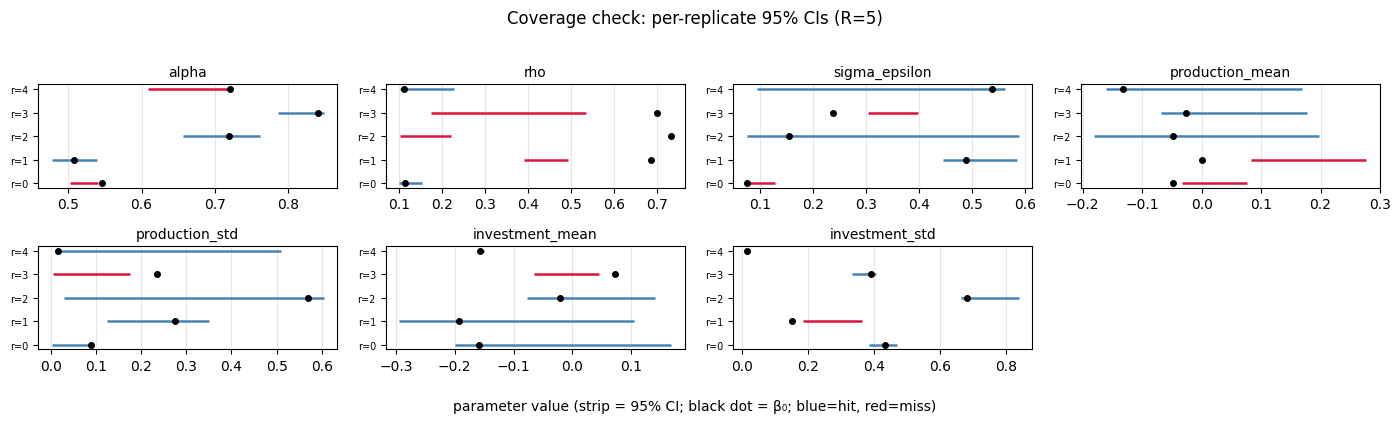

In [19]:
import math
n_params = len(spec.parameter_names)
n_cols = 4
n_rows = math.ceil(n_params / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 2.0 * n_rows), squeeze=False)
axes_flat = axes.ravel()
R_cov = cov_cfg.n_replicates
for ax, name in zip(axes_flat, spec.parameter_names):
    for r in range(R_cov):
        ci_lo, ci_hi = cov_result.per_replicate_intervals[r][name]
        beta0        = cov_result.per_replicate_beta0[r][name]
        hit          = ci_lo <= beta0 <= ci_hi
        color        = "steelblue" if hit else "crimson"
        ax.hlines(r, ci_lo, ci_hi, color=color, lw=1.8)
        ax.plot(beta0, r, marker="o", color="black", markersize=4)
    ax.set_title(name, fontsize=10)
    ax.set_yticks(range(R_cov))
    ax.set_yticklabels([f"r={r}" for r in range(R_cov)], fontsize=7)
    ax.grid(True, axis="x", alpha=0.3)
for ax in axes_flat[n_params:]:
    ax.set_visible(False)
fig.supxlabel("parameter value (strip = 95% CI; black dot = β₀; blue=hit, red=miss)", fontsize=10)
plt.suptitle(f"Coverage check: per-replicate 95% CIs (R={R_cov})", y=1.02)
plt.tight_layout()
plt.savefig(RUN_DIR / "coverage_intervals.png", dpi=140, bbox_inches="tight")
plt.show()

## Section 5: Posterior Predictive Check

Per Bayesian.md §1.4: draw `P["ppc_n_draws"]` β from the Section 3 posterior, synthesize one replicated panel per draw at the observed shape, compare 6 summary statistics between observed and replicated panels. Bayesian p-value per statistic = `P(T_rep > T_obs | y)`. Statistics:

- `y_mean`, `y_std`: cross-sectional mean and std of revenue.
- `log_k_mean`, `log_k_std`: cross-sectional mean and std of log capital.
- `log_k_growth_mean`: mean of `log_k_next - log_k` (drift, sensitive to $\mu_{\xi^k}$).
- `y_log_k_slope`: OLS slope of pooled `y` on pooled `log_k` (should recover $\alpha$).

Pass band: $p \in [0.05, 0.95]$ ("no glaring misfit"). Extremes flag features the model fails to reproduce.

In [9]:
ppc_cfg = PosteriorPredictiveConfig(n_draws=P["ppc_n_draws"], burn_in=20)
print(f"PPC: n_draws={ppc_cfg.n_draws} posterior samples, "
      f"observed shape ({P['n_firms']}, {P['horizon']})...")
ppc_seed = fold_in_seed(MASTER_SEED, "ppc")
t0 = time.time()
ppc = run_posterior_predictive_check(
    spec, result.posterior_samples, observed, ppc_cfg, seed=tuple(ppc_seed),
)
ppc_wall_sec = time.time() - t0
print(f"PPC wall = {ppc_wall_sec:.2f}s")

ppc_rows = []
for s in ppc_cfg.statistics:
    rep = ppc.replicated_stats[s]
    p   = ppc.bayes_p_values[s]
    ppc_rows.append({
        "statistic":       s,
        "observed":        ppc.observed_stats[s],
        "replicated_mean": float(np.mean(rep)),
        "replicated_std":  float(np.std(rep)),
        "bayes_p":         p,
        "in_central_90":   bool(0.05 <= p <= 0.95),
    })
ppc_table = pd.DataFrame(ppc_rows)
print(f"\nPPC summary (in-band rate = {ppc_table['in_central_90'].sum()} / {len(ppc_table)}):")
display(ppc_table)
ppc_table.to_csv(RUN_DIR / "ppc_summary.csv", index=False)

PPC: n_draws=100 posterior samples, observed shape (20, 10)...
PPC wall = 8.58s

PPC summary (in-band rate = 6 / 6):


,statistic,observed,replicated_mean,replicated_std,bayes_p,in_central_90
0,y_mean,1.214096,1.229285,0.068658,0.58,True
1,y_std,0.342606,0.367706,0.038260,0.76,True
2,log_k_mean,2.472309,2.484041,0.044987,0.57,True
3,log_k_std,0.270137,0.282146,0.027136,0.65,True
4,log_k_growth_mean,0.003207,0.000424,0.008082,0.35,True
5,y_log_k_slope,0.927094,0.972945,0.073935,0.76,True


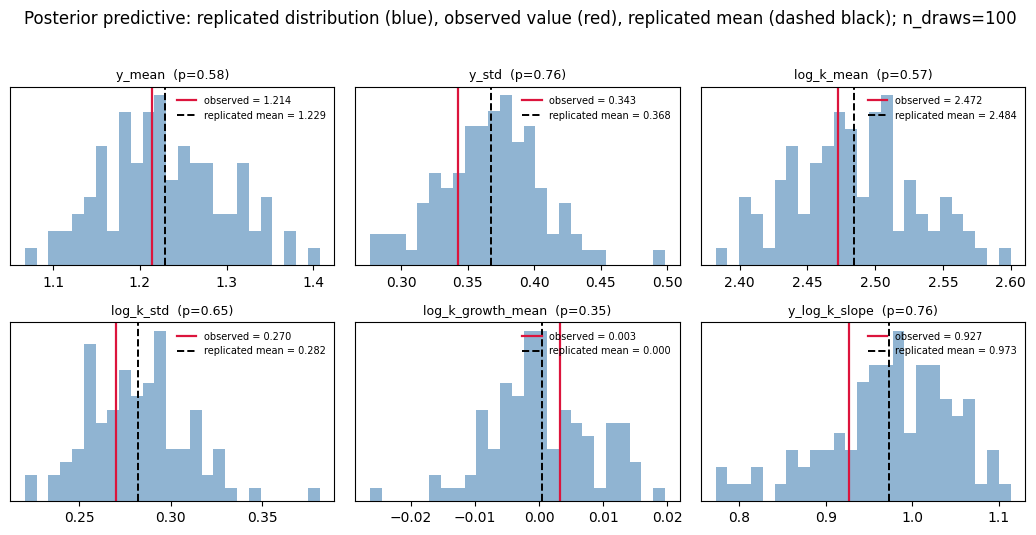

In [20]:
n_stats = len(ppc_cfg.statistics)
n_cols  = 3
n_rows  = (n_stats + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 2.6 * n_rows))
axes = np.atleast_2d(axes).reshape(-1)
for ax, s in zip(axes, ppc_cfg.statistics):
    rep      = ppc.replicated_stats[s]
    obs      = ppc.observed_stats[s]
    rep_mean = float(np.mean(rep))
    ax.hist(rep, bins=25, alpha=0.6, color="steelblue", density=True)
    ax.axvline(obs,      color="crimson", lw=1.6,
               label=f"observed = {obs:.3f}")
    ax.axvline(rep_mean, color="black", ls="--", lw=1.4,
               label=f"replicated mean = {rep_mean:.3f}")
    ax.set_title(f"{s}  (p={ppc.bayes_p_values[s]:.2f})", fontsize=9)
    ax.set_yticks([])
    ax.legend(loc="upper right", fontsize=7, frameon=False)
for ax in axes[len(ppc_cfg.statistics):]:
    ax.set_visible(False)
plt.suptitle(
    f"Posterior predictive: replicated distribution (blue), "
    f"observed value (red), replicated mean (dashed black); n_draws={ppc_cfg.n_draws}",
    y=1.02,
)
plt.tight_layout()
plt.savefig(RUN_DIR / "ppc_distributions.png", dpi=140, bbox_inches="tight")
plt.show()


## Section 6: Prior Sensitivity

Per Bayesian.md §1.4: re-run MCMC under three std-prior variants (`tight` HalfNormal(0.1) / `default` HalfNormal(0.5) / `loose` HalfNormal(1.0)) on `production_std` and `investment_std`. Mean priors (`Normal(0, 0.1)`) and the structural-triple uniforms are held fixed.

Movement metric per parameter: `|median_variant - median_default| / ci_width_default`. Rule of thumb:

- < 0.25: posterior is robust (data-driven, prior is non-binding)
- 0.25 - 0.5: moderate prior influence
- \> 0.5: posterior is sensitive (prior is constraining)

Expected at this profile: the structural triple ($\alpha, \rho, \sigma_\varepsilon$) is tightly identified by the likelihood and should be robust across variants. The residual std priors directly govern $\sigma_\eta, \sigma_{\xi^k}$ posteriors and may show 0.25 - 0.5 movement; $\mu_{\xi^k}$ inherits movement via the κ(α) ridge.

In [11]:
spec_factory = partial(make_closed_form_bayesian_spec, param_env)
sens_run_cfg = BayesianRunConfig(
    n_chains=SENSITIVITY_INNER["n_chains"],
    n_warmup=SENSITIVITY_INNER["n_warmup"],
    n_samples=SENSITIVITY_INNER["n_samples"],
    target_accept_prob=SENSITIVITY_INNER["target_accept_prob"],
    master_seed=tuple(MASTER_SEED),
)
sens_seed = fold_in_seed(MASTER_SEED, "sensitivity")
print(f"Sensitivity: {len(SENSITIVITY_VARIANTS)} variants "
      f"(inner: {sens_run_cfg.n_chains} chains x "
      f"{sens_run_cfg.n_warmup}+{sens_run_cfg.n_samples} iters per variant)...")
t0 = time.time()
sens = run_prior_sensitivity(
    spec_factory, SENSITIVITY_VARIANTS, observed, sens_run_cfg,
    seed=tuple(sens_seed), default_variant_name="default",
)
sens_wall_sec = time.time() - t0
print(f"Sensitivity wall = {sens_wall_sec:.1f}s "
      f"({sens_wall_sec/len(SENSITIVITY_VARIANTS):.1f}s per variant)")

# Per-variant per-param summary.
sens_rows = []
for variant in SENSITIVITY_VARIANTS:
    for name in spec.parameter_names:
        entry = sens.posterior_summaries[variant][name]
        sens_rows.append({"variant": variant, "parameter": name, **entry})
sens_table = pd.DataFrame(sens_rows)
sens_table.to_csv(RUN_DIR / "sensitivity_summary.csv", index=False)

# Movement table: max non-default-variant movement per param, robust flag.
mov_rows = []
nondef = [v for v in SENSITIVITY_VARIANTS if v != "default"]
for name in spec.parameter_names:
    row = {"parameter": name, "default_ci_width": sens.default_ci_widths[name]}
    for v in nondef:
        row[f"{v}_movement"] = sens.movement_metrics[v][name]
    max_mov = max(sens.movement_metrics[v][name] for v in nondef)
    row["max_movement"] = max_mov
    row["robust"] = bool(max_mov < 0.25)
    mov_rows.append(row)
mov_table = pd.DataFrame(mov_rows)
print(f"\nSensitivity movement (robust rate = {mov_table['robust'].sum()} / {len(mov_table)}):")
display(mov_table)
mov_table.to_csv(RUN_DIR / "sensitivity_movement.csv", index=False)

Sensitivity: 3 variants (inner: 2 chains x 500+200 iters per variant)...
Sensitivity wall = 1522.6s (507.5s per variant)

Sensitivity movement (robust rate = 7 / 7):


,parameter,default_ci_width,tight_movement,loose_movement,max_movement,robust
0,alpha,0.040163,0.007336,0.033550,0.033550,True
1,rho,0.046260,0.058855,0.013235,0.058855,True
2,sigma_epsilon,0.049853,0.019420,0.030938,0.030938,True
3,production_mean,0.131303,0.001694,0.022193,0.022193,True
4,production_std,0.058441,0.023557,0.013709,0.023557,True
5,investment_mean,0.319782,0.010385,0.029995,0.029995,True
6,investment_std,0.040012,0.004600,0.010705,0.010705,True


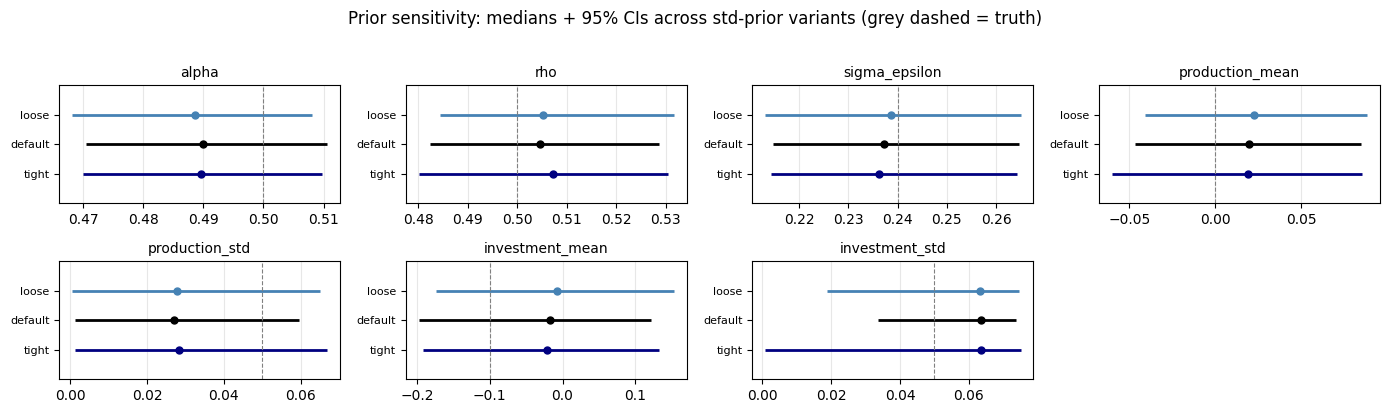

In [18]:
variant_order   = ["tight", "default", "loose"]
variant_offsets = {"tight": -0.25, "default": 0.0, "loose": 0.25}
variant_colors  = {"tight": "navy", "default": "black", "loose": "steelblue"}

n_params = len(spec.parameter_names)
n_cols = 4
n_rows = math.ceil(n_params / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 2.0 * n_rows), squeeze=False)
axes_flat = axes.ravel()
for ax, name in zip(axes_flat, spec.parameter_names):
    for variant in variant_order:
        entry = sens.posterior_summaries[variant][name]
        y = variant_offsets[variant]
        ax.hlines(y, entry["ci_lo"], entry["ci_hi"], color=variant_colors[variant], lw=2.0)
        ax.plot(entry["median"], y, marker="o", color=variant_colors[variant], markersize=5)
    ax.axvline(beta_true[name], color="grey", lw=0.8, ls="--")
    ax.set_yticks([variant_offsets[v] for v in variant_order])
    ax.set_yticklabels(variant_order, fontsize=8)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(-0.5, 0.5)
    ax.grid(True, axis="x", alpha=0.3)
for ax in axes_flat[n_params:]:
    ax.set_visible(False)
plt.suptitle("Prior sensitivity: medians + 95% CIs across std-prior variants (grey dashed = truth)",
             y=1.02)
plt.tight_layout()
plt.savefig(RUN_DIR / "sensitivity_comparison.png", dpi=140, bbox_inches="tight")
plt.show()
